In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score

from sklearn.preprocessing import KBinsDiscretizer
from sklearn.compose import ColumnTransformer

In [2]:
df = pd.read_csv(r"C:\Users\gsksd\Downloads\train.csv" , usecols=['Age' , 'Fare' , 'Survived'])

In [3]:
df.sample(5)

,Survived,Age,Fare
839,1,NaN,29.7000
327,1,36.0,13.0000
698,0,49.0,110.8833
403,0,28.0,15.8500
322,1,30.0,12.3500


In [4]:
df.dropna(inplace=True)

In [5]:
df.shape

(714, 3)

## Before Binning resullts

In [6]:
X = df.iloc[:,1:]
y = df.iloc[:,0]

In [7]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [8]:
X_train.shape

(571, 2)

In [9]:
clf = DecisionTreeClassifier()

In [10]:
clf.fit(X_train,y_train)
y_pred = clf.predict(X_test)

In [11]:
accuracy_score(y_test,y_pred)

0.6363636363636364

In [12]:
np.mean(cross_val_score(DecisionTreeClassifier(),X,y,cv=10,scoring='accuracy'))

np.float64(0.6275039123630674)

## Binning 

In [16]:
 Kbin_Age  = KBinsDiscretizer(n_bins=10 , encode='ordinal' , strategy='uniform')
 Kbin_Fare = KBinsDiscretizer(n_bins=10 , encode='ordinal' , strategy='uniform')

In [17]:
trf = ColumnTransformer(
    [
        ('First' , Kbin_Age ,[0]), 
        ('Second' ,Kbin_Fare , [1])
    ]
)

In [18]:
X_train_trf = trf.fit_transform(X_train)
X_test_trf = trf.transform(X_test)

In [21]:
trf.named_transformers_['First']

,"n_bins n_bins: int or array-like of shape (n_features,), default=5The number of bins to produce. Raises ValueError if ``n_bins < 2``.",10
,"encode encode: {'onehot', 'onehot-dense', 'ordinal'}, default='onehot'Method used to encode the transformed result.- 'onehot': Encode the transformed result with one-hot encoding and return a sparse matrix. Ignored features are always stacked to the right.- 'onehot-dense': Encode the transformed result with one-hot encoding and return a dense array. Ignored features are always stacked to the right.- 'ordinal': Return the bin identifier encoded as an integer value.",'ordinal'
,"strategy strategy: {'uniform', 'quantile', 'kmeans'}, default='quantile'Strategy used to define the widths of the bins.- 'uniform': All bins in each feature have identical widths.- 'quantile': All bins in each feature have the same number of points.- 'kmeans': Values in each bin have the same nearest center of a 1D k-means cluster.For an example of the different strategies see::ref:`sphx_glr_auto_examples_preprocessing_plot_discretization_strategies.py`.",'uniform'
,"quantile_method quantile_method: {""inverted_cdf"", ""averaged_inverted_cdf"",""closest_observation"", ""interpolated_inverted_cdf"", ""hazen"",""weibull"", ""linear"", ""median_unbiased"", ""normal_unbiased""},default=""averaged_inverted_cdf""Method to pass on to np.percentile calculation when usingstrategy=""quantile"". Only `averaged_inverted_cdf` and `inverted_cdf`support the use of `sample_weight != None` when subsampling is notactive... versionadded:: 1.7.. versionchanged:: 1.9 The default value changed from `""linear""` to `""averaged_inverted_cdf""`.",'averaged_inverted_cdf'
,"dtype dtype: {np.float32, np.float64}, default=NoneThe desired data-type for the output. If None, output dtype isconsistent with input dtype. Only np.float32 and np.float64 aresupported... versionadded:: 0.24",None
,"subsample subsample: int or None, default=200_000Maximum number of samples, used to fit the model, for computationalefficiency.`subsample=None` means that all the training samples are used whencomputing the quantiles that determine the binning thresholds.Since quantile computation relies on sorting each column of `X` andthat sorting has an `n log(n)` time complexity,it is recommended to use subsampling on datasets with avery large number of samples... versionchanged:: 1.3 The default value of `subsample` changed from `None` to `200_000` when `strategy=""quantile""`... versionchanged:: 1.5 The default value of `subsample` changed from `None` to `200_000` when `strategy=""uniform""` or `strategy=""kmeans""`.",200000
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for subsampling.Pass an int for reproducible results across multiple function calls.See the `subsample` parameter for more details.See :term:`Glossary <random_state>`... versionadded:: 1.1",None
Name,Type,Value
"bin_edges_ bin_edges_: ndarray of ndarray of shape (n_features,)The edges of each bin. Contain arrays of varying shapes ``(n_bins_, )``Ignored features will have empty arrays.","ndarray[object](1,)","[array([ 0.42 , 8.378, 16.336, 24.294, 32.252, 40.21 , 48.168, 56.126, 64.084, 72.042, 80. ]) ]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['Age']
"n_bins_ n_bins_: ndarray of shape (n_features,), dtype=np.int64Number of bins per feature. Bins whose width are too small(i.e., <= 1e-8) are removed with a warning.","ndarray[int64](1,)",[10]


In [22]:
output = pd.DataFrame({
    'age':X_train['Age'],
    'age_trf':X_train_trf[:,0],
    'fare':X_train['Fare'],
    'fare_trf':X_train_trf[:,1]
})

In [24]:
output['age_labels'] = pd.cut(x=X_train['Age'],
                                    bins=trf.named_transformers_['First'].bin_edges_[0].tolist())
output['fare_labels'] = pd.cut(x=X_train['Fare'],
                                    bins=trf.named_transformers_['Second'].bin_edges_[0].tolist())

In [25]:
output.sample(5)

,age,age_trf,fare,fare_trf,age_labels,fare_labels
183,1.0,0.0,39.0000,0.0,"(0.42, 8.378]","(0.0, 51.233]"
642,2.0,0.0,27.9000,0.0,"(0.42, 8.378]","(0.0, 51.233]"
834,18.0,2.0,8.3000,0.0,"(16.336, 24.294]","(0.0, 51.233]"
586,47.0,5.0,15.0000,0.0,"(40.21, 48.168]","(0.0, 51.233]"
858,24.0,2.0,19.2583,0.0,"(16.336, 24.294]","(0.0, 51.233]"


In [26]:
clf = DecisionTreeClassifier()
clf.fit(X_train_trf,y_train)
y_pred2 = clf.predict(X_test_trf)

In [27]:
accuracy_score(y_test,y_pred2)

0.6783216783216783

In [28]:
def discretize(bins,strategy):
    kbin_age = KBinsDiscretizer(n_bins=bins,encode='ordinal',strategy=strategy)
    kbin_fare = KBinsDiscretizer(n_bins=bins,encode='ordinal',strategy=strategy)
    
    trf = ColumnTransformer([
        ('first',kbin_age,[0]),
        ('second',kbin_fare,[1])
    ])
    
    X_trf = trf.fit_transform(X)
    print(np.mean(cross_val_score(DecisionTreeClassifier(),X,y,cv=10,scoring='accuracy')))
    
    plt.figure(figsize=(14,4))
    plt.subplot(121)
    plt.hist(X['Age'])
    plt.title("Before")

    plt.subplot(122)
    plt.hist(X_trf[:,0],color='red')
    plt.title("After")

    plt.show()
    
    plt.figure(figsize=(14,4))
    plt.subplot(121)
    plt.hist(X['Fare'])
    plt.title("Before")

    plt.subplot(122)
    plt.hist(X_trf[:,1],color='red')
    plt.title("Fare")

    plt.show()

C:\Users\gsksd\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
C:\Users\gsksd\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


0.6373043818466353


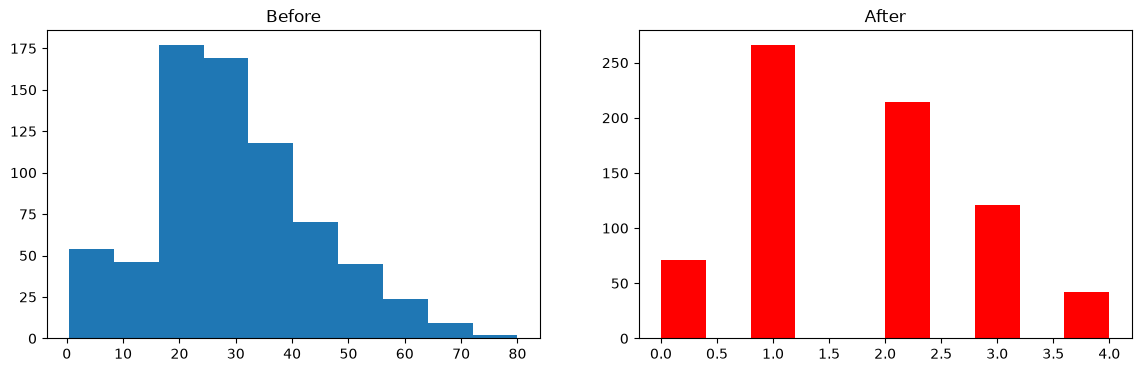

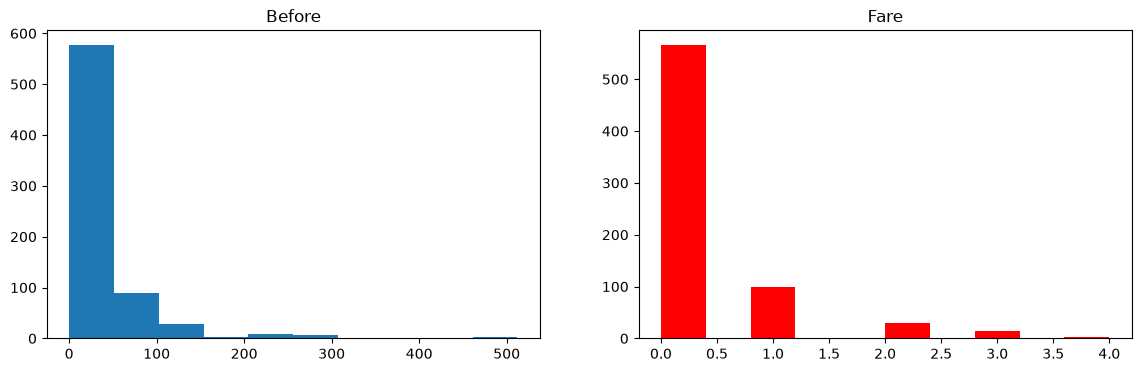

In [30]:
discretize(5,'kmeans')